# Universität Hildesheim - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Universität Hildesheim' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/02f9det96' -- 'Universität Hildesheim'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Universität Hildesheim,"University of Hildesheim, Germany",https://openalex.org/W4286542483
1,not assigned,Universität Hildesheim,"Institute of Social Sciences, University Hilde...",https://openalex.org/W4286007852
2,not assigned,Universität Hildesheim,Information Systems and Machine Learning Lab U...,https://openalex.org/W4210597512
3,not assigned,Universität Hildesheim,"Information Systems and Machine Learning Lab, ...",https://openalex.org/W4210597512
4,not assigned,Universität Hildesheim,Universität Hildesheim,https://openalex.org/W4390869900


In [22]:
MAPPING_DICT = {
    'Center for World Music (CWM)': ['center for world music'],
    'Centrum für Lehrerbildung und Bildungsforschung (CeLeB)': ['lehrerbildung'],
    'Fachbereich I: Erziehungs- und Sozialwissenschaften': ['education(al)? science', 'psycholog(ie|y)', 'sport', 'erziehungswissenschaft',
                                                            'so(z|c)ial', 'grundschuldidaktik', 'theologie', 'geschichte', '(institute|faculty) of education',
                                                            'psychopathology', 'migration', 'research methods'
                                                           ],
    'Fachbereich II: Kulturwissenschaften und Ästhetische Kommunikation': ['english', 'philosoph(ie|y)', 'kulturpolitik', 'musikwissenschaft',
                                                                           'cultural policy'
                                                                          ],
    'Fachbereich III: Sprach- und Informationswissenschaften': ['language (science|processing)', 'linguistics', 'deutsche sprache', 'informationswissenschaften',
                                                                'sprachtechnologie', '(?<!economics\sand\s)information science', 'inter(k|c)ultur(elle|al)',
                                                                'übersetzungswissenschaft', 'german language', 'speciali(s|z)ed communication'
                                                               ],
    'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik': ['institut für informatik', 'ecology', 'machine learning',
                                                                                   'biolog(ie|y)', 'angewandte informatik', 'business administration',
                                                                                   'mat(h)?emati(k|cs)', 'geograph(ie|y)', 'information systems',
                                                                                   'computer science', 'software systems engineering', 'wirtschaftsinformatik',
                                                                                   'data analytics', 'ismll,', 'economics education'
                                                                                  ],
    'Universitätsbibliothek': ['universitätsbibliothek', 'university library'],
    #'Zentrum für Geschlechterforschung': []
}

In [23]:
with open('./mapping_tables_fak/hildesheim.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [24]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [25]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [26]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,Universität Hildesheim,"University of Hildesheim, Germany",https://openalex.org/W4286542483
1,Fachbereich I: Erziehungs- und Sozialwissensch...,Universität Hildesheim,"Institute of Social Sciences, University Hilde...",https://openalex.org/W4286007852
2,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Information Systems and Machine Learning Lab U...,https://openalex.org/W4210597512
3,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Information Systems and Machine Learning Lab, ...",https://openalex.org/W4210597512
4,None,Universität Hildesheim,Universität Hildesheim,https://openalex.org/W4390869900
...,...,...,...,...
1552,None,Universität Hildesheim,Stiftung Universität Hildesheim (UB Hildesheim),https://openalex.org/W3210044066
1553,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Department of Biology, University of Hildeshei...",https://openalex.org/W3080196716
1554,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Department of Biology University of Hildesheim...,https://openalex.org/W3080196716
1555,None,Universität Hildesheim,"University of Hildesheim, Hildesheim, Germany",https://openalex.org/W3004644776


In [27]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['University of Hildesheim, Germany', 'Universität Hildesheim',
       'University of Hildesheim', 'Universität Hildesheim, Hildesheim',
       'University of Hildesheim, Hildesheim, Germany',
       'Hildesheim University, Hildesheim, Germany',
       'Stiftung Universität Hildesheim (UB Hildesheim)',
       'Universität Hildesheim, Hildesheim, Germany',
       'University of Hildesheim Hildesheim, Germany',
       'University of Hildesheim Hildeheim, Germany',
       'Stiftung Universität Hildesheim',
       'Professor of Law, University of Hildesheim, Hildesheim, Germany',
       'DFKI/ University of Hildesheim',
       'University of Hildesheim,Robert Bosch GmbH,Hildesheim,Germany',
       'Robert Bosch GmbH, University of Hildesheim, Hildesheim, Germany',
       'University of Hildesheim,Hildesheim,Germany',
       'University of Hildesheim, Germany, --- Select a Country ---',
       'Institut für Literarisches Schreiben & Literaturwissenschaft , Universitätsplatz 1, 31141 H

In [28]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Center for World Music (CWM),1
1,Centrum für Lehrerbildung und Bildungsforschun...,4
2,Fachbereich I: Erziehungs- und Sozialwissensch...,529
3,Fachbereich II: Kulturwissenschaften und Ästhe...,38
4,Fachbereich III: Sprach- und Informationswisse...,119
5,"Fachbereich IV: Mathematik, Naturwissenschafte...",359
6,Universitätsbibliothek,9
7,NaN,498


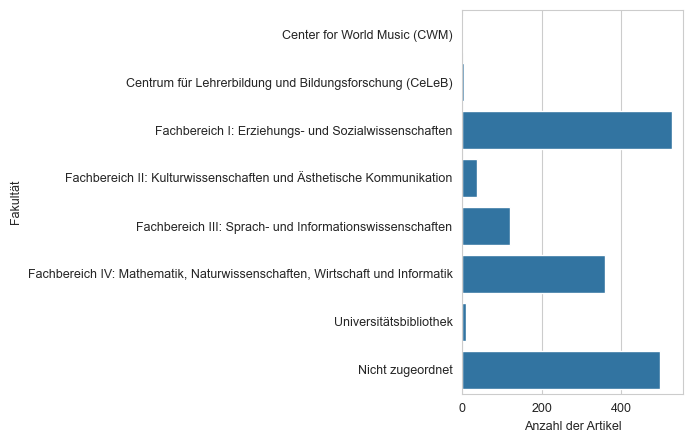

In [29]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [30]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.6801541425818882

In [15]:
MAPPING_DICT_DEPT = {
    'Fachbereich I: Erziehungs- und Sozialwissenschaften': {
        'Institut für Erziehungswissenschaft': ['erziehungswissenschaft', 'applied educational science', 'general education', '(department|institute) (for|of) educational science'],
        'Institut für Evangelische Theologie': ['evangelische theologie'],
        'Institut für Geschichte': ['institut für geschichte'],
        'Institut für Grundschuldidaktik und Sachunterricht': ['grundschuldidaktik'],
        'Institut für Katholische Theologie': ['katholische theologie'],
        'Institut für Psychologie': ['psycholog(ie|y)', 'psychopathology'],
        'Institut für Sozial- und Organisationspädagogik': ['organisationspädagogik', 'organi(s|z)ation(al)? (studies|education)', 'organi(s|z)ational pedagogy'],
        'Institut für Sozialwissenschaften': ['(department|institute) (of|for) social sciences', 'institut für sozialwissenschaften', 'migration policy'],
        'Institut für Sportwissenschaft': ['biosciences of sports', 'sport(s)? science', 'sportwissen(-)?schaft'],
    },
    'Fachbereich II: Kulturwissenschaften und Ästhetische Kommunikation': {
        'Institut für Bildende Kunst und Kunstwissenschaft': ['kunstwissenschaft'],
        'Institut für Kulturpolitik': ['cultural policy', 'kulturpolitik'],
        'Institut für Literarisches Schreiben und Literaturwissenschaft': ['(department|institute) of english', 'english department'],
        'Institut für Medien, Theater und Populäre Kultur': ['populäre kultur'],
        'Institut für Musik und Musikwissenschaft': ['musikwissenschaft'],
        'Institut für Philosophie': ['philosoph(ie|y)'],
    },
    'Fachbereich III: Sprach- und Informationswissenschaften': {
        'Institut für deutsche Sprache und Literatur': ['deutsche sprache', 'german language'],
        'Institut für englische Sprache und Literatur': ['englische sprache'],
        'Institut für Informationswissenschaft und Sprachtechnologie': ['language processing', 'sprachtechnologie', '(language|speech) (technology|science)'],
        'Institut für Interkulturelle Kommunikation': ['interkulturelle', 'intercultural'],
        'Institut für Übersetzungswissenschaft und Fachkommunikation': ['übersetzungswissenschaft'],
    },
    'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik': {
        'Institut für Betriebswirtschaft und Wirtschaftsinformatik': ['ismll,', 'betriebswirtschaft', 'wirtschaftsinformatik', 'economics education', 'data analytics',
                                                                      'business administration'
                                                                     ],
        'Institut für Biologie und Chemie': ['biolog(ie|y)', 'zoology', 'plant ecology', 'chemie'],
        'Institut für Geographie': ['geograph(ie|y)', 'geoecology'],
        'Institut für Informatik': ['(information|software) systems', 'institut für informatik', 'computer science'],
        'Institut für Mathematik, Mathematikdidaktik und Informatikdidaktik': ['insti(t)?ute (of|for) mathematics', 'institut f(ü|u)?r (angewandte\s)?mathematik'],
        'Institut für Physik': ['institut für physik'],
        'Institut für Technik': ['institut für technik'],
    }
}

In [16]:
with open('./mapping_tables_dept/hildesheim.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [17]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [18]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik']['raw_affiliation_string'].apply(map_dept, 
                                                                                                    faculty='Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik')

In [19]:
df_with_inst[(df_with_inst['fak_name'] == 'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Leibniz-Institut für die Pädagogik der Naturwissenschaften und Mathematik, Kiel and Universität Hildesheim',
       'Research Group Ecology and Environmental Education, University of Hildesheim, Universitaetsplatz 1, 31141, Hildesheim, Germany'],
      dtype=object)

In [20]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Institut für Betriebswirtschaft und Wirtschaft...,36
1,Institut für Biologie und Chemie,140
2,Institut für Geographie,54
3,Institut für Informatik,84
4,"Institut für Mathematik, Mathematikdidaktik un...",43
5,NaN,2


In [21]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
2,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Information Systems and Machine Learning Lab U...,https://openalex.org/W4210597512,Institut für Informatik
3,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Information Systems and Machine Learning Lab, ...",https://openalex.org/W4210597512,Institut für Informatik
6,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Faculty for Mathematics, Natural Sciences, Eco...",https://openalex.org/W4307046931,Institut für Informatik
10,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Department of Biology and Chemistry, Universit...",https://openalex.org/W4229075418,Institut für Biologie und Chemie
12,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Institut für Mathematik und Angewandte Informa...,https://openalex.org/W4225749428,"Institut für Mathematik, Mathematikdidaktik un..."
...,...,...,...,...,...
1523,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Operations Research Group, Institute of Busine...",https://openalex.org/W3007115912,Institut für Informatik
1533,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Institut für Betriebswirtschaft und Wirtschaft...,https://openalex.org/W3005951495,Institut für Betriebswirtschaft und Wirtschaft...
1553,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Department of Biology, University of Hildeshei...",https://openalex.org/W3080196716,Institut für Biologie und Chemie
1554,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Department of Biology University of Hildesheim...,https://openalex.org/W3080196716,Institut für Biologie und Chemie
